# Домашнее задание 1. Autoencoders & Fréchet Inception Distance

В этом задании вы:
1. Напишете свой автоэнкодер (AE) для датасета CIFAR10.
2. Используете эмбеддинги энкодера, чтобы посчитать Fréchet Inception Distance (FID) между классами CIFAR10.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import Subset, DataLoader
from torchvision import datasets, transforms

from sklearn.ensemble import GradientBoostingClassifier

from tqdm.auto import tqdm, trange

from collections import defaultdict
import random

from scipy.linalg import sqrtm

/home/avomilas/.pyenv/versions/3.12.5/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def set_seed(seed: int):
    """
    Sets the seed for reproducibility across numpy, random, torch.

    Parameters:
    seed (int): The seed value to be set.
    """
    random.seed(seed)  # Python's random module
    np.random.seed(seed)  # NumPy
    torch.manual_seed(seed)  # Torch for CPU and device-agnostic
    torch.cuda.manual_seed(seed)  # GPU: CUDA 
    torch.cuda.manual_seed_all(seed)  # Multi-GPU
    torch.backends.cudnn.deterministic = True  # Deterministic behavior for CUDA
    torch.backends.cudnn.benchmark = False  # Disable cuDNN benchmarking

SEED = 42
set_seed(SEED)

In [3]:
device: str = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
device

'cpu'

Для работы с данными будем использовать `torchvision`.

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    lambda x: (x * 2) - 1
])

In [5]:
train_dataset = datasets.CIFAR10(
    '../data/cifar',
    train=True,
    transform=transform,
    download=True)
val_dataset = datasets.CIFAR10(
    '../data/cifar',
    train=False,
    transform=transform,
    download=True)
len(train_dataset), len(val_dataset)

Files already downloaded and verified
Files already downloaded and verified


(50000, 10000)

Нам нужно будет уметь «разнормализовать» картинки (обратно в $[0,1]$) для визуализации.

In [6]:
def denormalize_image(image):
    return (image + 1) / 2

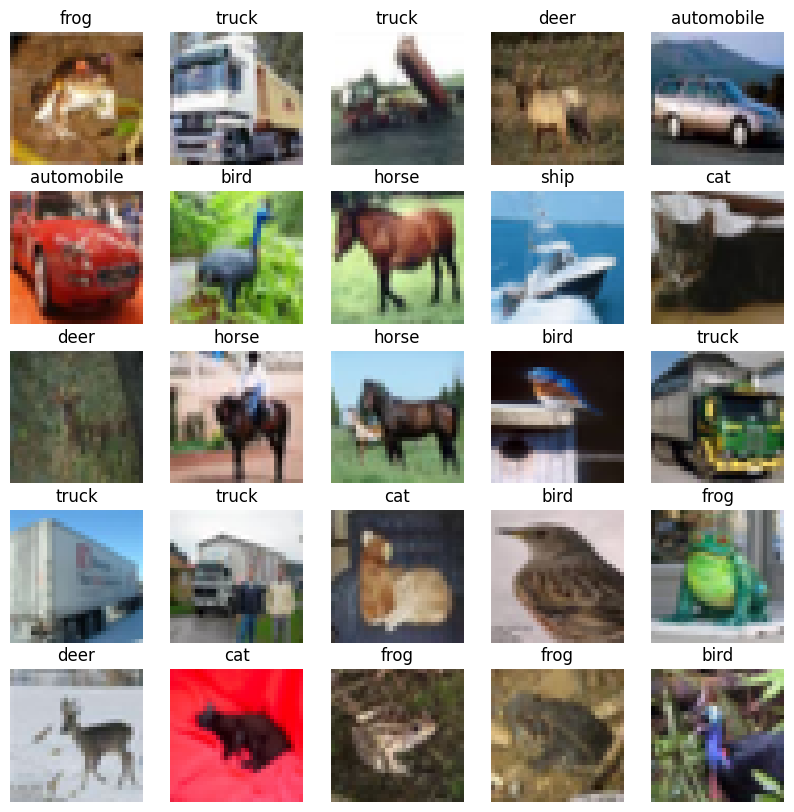

In [7]:
text_labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(10, 10))
for index, (image, label) in enumerate(train_dataset):
    plt.subplot(5, 5, index + 1)
    plt.imshow(denormalize_image(image.permute(1, 2, 0)))
    plt.axis('off')
    plt.title(text_labels[label])
    if index == 24: break
plt.show()

Размерность картинки в CIFAR10: 3 канала, 32×32 пикселя.

In [8]:
image.shape

torch.Size([3, 32, 32])

In [9]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
len(train_loader), len(val_loader)

(391, 10000)

## Задание 1. Обучить AE (3 балла)

Постройте свой AE: напишите классы `Encoder` и `Decoder`. Можно использовать любые слои, которые посчитаете нужными: `nn.Conv2d`, `nn.AvgPool2d`, `nn.MaxPool2d`, а также в декодере — `nn.Upsample`, `nn.ConvTranspose2d` и т.д.  

![](https://miro.medium.com/max/1400/1*44eDEuZBEsmG_TCAKRI3Kw@2x.png)

In [12]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        ### BEGIN SOLUTION
        # Ваш код здесь
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, stride=2, padding=1),  
            nn.ReLU(),
            nn.Conv2d(8, 8, kernel_size=3, stride=2, padding=1),  
            nn.ReLU(),
            nn.Conv2d(8, 8, kernel_size=3, stride=2, padding=1),  
            nn.ReLU(),
        )
        ### END SOLUTION

    def forward(self, x):
        ### BEGIN SOLUTION
        # Ваш код здесь
        return self.encoder(x)
        ### END SOLUTION

In [13]:
encoder = Encoder()
noise = torch.rand(1, 3, 32, 32) - 1
assert encoder(noise).view(-1).shape[0] < 1*3*32*32, "Размер эмбеддинга должен быть меньше исходного!"

In [14]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        ### BEGIN SOLUTION
        # Ваш код здесь
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 8, kernel_size=3, stride=2, padding=1),  
            nn.ReLU(),
            nn.Conv2d(8, 3, kernel_size=3, stride=2, padding=1),  
            nn.ReLU(),
            nn.Upsample(scale_factor=8, mode="bilinear", align_corners=True)
        )

        ### END SOLUTION

    def forward(self, z):
        ### BEGIN SOLUTION
        # Ваш код здесь
        return self.decoder(z)
        ### END SOLUTION

In [15]:
decoder = Decoder()
noise = torch.rand(1, 3, 32, 32)
emb = encoder(noise)
# decoder(emb).shape
assert decoder(emb).shape == (1, 3, 32, 32), "Декодер должен восстанавливать тензор формы (batch_size, 3, 32, 32)"

Для оценки качества энкодера возьмём его выходы как фичи для классификации (Gradient Boosting). Затем сравним скор классификации для необученного энкодера со скором обученного. Для ускорения расчета, мы используем только часть трейна.

In [126]:
def classification_score(encoder, _train_dataset, val_dataset, device, train_size=5000):
    encoder.eval()
    
    # Возьмём train_size случайных примеров для обучения GBDT
    train_dataset = Subset(_train_dataset, torch.randperm(len(_train_dataset))[:train_size])
    
    X_train = []
    y_train = []
    for image, label in tqdm(train_dataset):
        image = image.to(device)
        with torch.no_grad():
            emb = encoder(image[None, ...])
        X_train.append(emb.cpu().numpy().reshape(-1))
        y_train.append(label)
    X_train = np.stack(X_train)
    y_train = np.stack(y_train)
    
    clf = GradientBoostingClassifier(n_estimators=50, max_depth=5, verbose=1, random_state=SEED)
    clf.fit(X_train, y_train)
    
    X_val = []
    y_val = []
    for image, label in tqdm(val_dataset):
        image = image.to(device)
        with torch.no_grad():
            emb = encoder(image[None, ...])
        X_val.append(emb.cpu().numpy().reshape(-1))
        y_val.append(label)
    X_val = np.stack(X_val)
    y_val = np.stack(y_val)
    
    return clf.score(X_val, y_val)

In [ ]:
pretrain_score = classification_score(Encoder().to(device), train_dataset, val_dataset, device)
pretrain_score

  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [00:13<00:00, 379.27it/s]


      Iter       Train Loss   Remaining Time 
         1           2.1212           30.72m
         2           1.9815           30.65m


Напишите функцию `train`, которая обучает энкодер и декодер на **всём трейне**, возвращая средний MSE.

In [22]:
def train(loader, optim, encoder, decoder, device):
    encoder.train()
    decoder.train()
    criterion = nn.MSELoss()
    losses = []
    for image, _ in tqdm(loader, leave=False):
        ### BEGIN SOLUTION
        # Ваш код здесь
        optim.zero_grad()

        image = image.to(device)
        encoded = encoder(image)
        reconstructed = decoder(encoded)
        loss = criterion(reconstructed, image)
        losses.append(loss.item())

        loss.backward()
        optim.step()
        ### END SOLUTION
    return sum(losses) / len(losses)

In [23]:
encoder.to(device)
decoder.to(device)

params = list(encoder.parameters()) + list(decoder.parameters())
optim = torch.optim.AdamW(params)

loss = train(train_loader, optim, encoder, decoder, device)
assert type(loss) == float, "Функция train должна возвращать float"
assert 0 < loss < 1
loss

  0%|          | 0/391 [00:00<?, ?it/s]

0.18508870701503266

Напишите функцию `eval`, которая возвращает среднее MSE на всём валидационном датасете.  
Hint: Не забудьте выключить расчёт градиентов.

In [24]:
def eval(loader, encoder, decoder, device):
    encoder.eval()
    decoder.eval()
    criterion = nn.MSELoss()
    losses = []
    with torch.no_grad():
        for image, _ in tqdm(loader, leave=False):
            ### BEGIN SOLUTION
            # Ваш код здесь
            image = image.to(device)
            encoded = encoder(image)
            reconstructed = decoder(encoded)
            loss = criterion(reconstructed, image)
            losses.append(loss.item())
            ### END SOLUTION
    return sum(losses) / len(losses)

In [25]:
loss = eval(val_loader, encoder, decoder, device)
assert type(loss) == float
assert 0 < loss < 1
loss

  0%|          | 0/10000 [00:00<?, ?it/s]

0.1815345519512426

Ниже — функция `full_train`, которая возвращает обученныe энкодер и декодер. Обучите модель, а затем добавьте загрузку предобученных весов в начало функции.

In [10]:
def full_train(device, train_loader, val_loader, pretrained_weights=None):
    encoder = Encoder().to(device)
    decoder = Decoder().to(device)
    
    ### BEGIN SOLUTION
    # Ваш код здесь
    
    if pretrained_weights:
        checkpoint = torch.load(pretrained_weights, map_location=device, weights_only=True)
        encoder.load_state_dict(checkpoint["encoder"])
        decoder.load_state_dict(checkpoint["decoder"])
        print("Предобученные веса загружены")
        return encoder, decoder
    ### END SOLUTION
    
    params = list(encoder.parameters()) + list(decoder.parameters())
    optim = torch.optim.AdamW(params)
    train_loss = []
    val_loss = []
    n_epochs = 30
    for e in trange(n_epochs):
        e_train_loss = train(train_loader, optim, encoder, decoder, device)
        train_loss.append(e_train_loss)
        e_val_loss = eval(val_loader, encoder, decoder, device)
        val_loss.append(e_val_loss)
        print(f'Epoch: {e+1}/{n_epochs}')
        print(f'Train MSE loss: {e_train_loss:.4f}')
        print(f'Validation MSE loss: {e_val_loss:.4f}')
    plt.plot(train_loss, label='train')
    plt.plot(val_loss, label='val')
    plt.legend()
    plt.title('MSE Loss')
    plt.grid()
    plt.show()
    return encoder, decoder

In [16]:
encoder, decoder = full_train(device, train_loader, val_loader, "checkpoint.pth")

Предобученные веса загружены


In [46]:
# torch.save({
#     "encoder": encoder.state_dict(),
#     "decoder": decoder.state_dict()
# }, "checkpoint.pth")

In [29]:
score = classification_score(encoder, train_dataset, val_dataset, device, train_size=5000)
assert score > pretrain_score * 1.05, "Слишком низкий скор. Убедитесь, что ваш AE обучается."
score

100%|██████████| 5000/5000 [00:06<00:00, 757.03it/s] 


      Iter       Train Loss   Remaining Time 
         1           2.1067            5.97m
         2           1.9664            5.87m
         3           1.8549            5.81m
         4           1.7572            5.69m
         5           1.6753            5.55m
         6           1.6029            5.40m
         7           1.5340            5.27m
         8           1.4742            5.15m
         9           1.4177            5.02m
        10           1.3675            4.88m
        20           1.0022            3.66m
        30           0.7833            2.46m
        40           0.6324            1.23m
        50           0.5263            0.00s


100%|██████████| 10000/10000 [00:11<00:00, 876.91it/s]


0.3938

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..1.0002329].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..1.0984653].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..1.0002911].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..1.0117332].


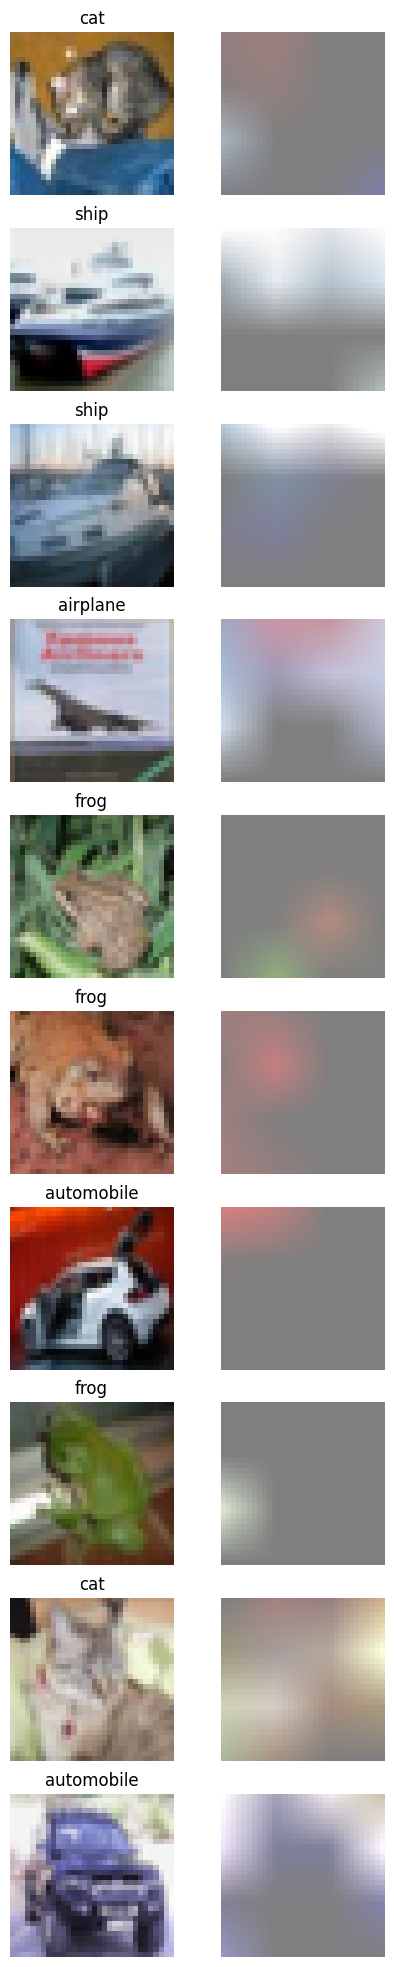

In [30]:
encoder.eval()
decoder.eval()
plt.figure(figsize=(5, 25))
for index, (image, label) in enumerate(val_loader):
    plt.subplot(10, 2, index*2 + 1)
    plt.imshow(denormalize_image(image)[0].permute(1, 2, 0))
    plt.axis('off')
    plt.title(text_labels[label])
    
    plt.subplot(10, 2, index*2 + 2)
    image = image.to(device)
    with torch.no_grad():
        emb = encoder(image)
        rec = decoder(emb).cpu()
    plt.imshow(denormalize_image(rec)[0].permute(1, 2, 0))
    plt.axis('off')
    
    if index == 9:
        break

## Задание 2. FID дистанция между классами CIFAR10 (3 балла)

Теперь, используя bottleneck-представления обученного энкодера, посчитаем **Fréchet Inception Distance (FID)** между разными классами CIFAR10 на **валидационной** выборке.

Напомним формулу FID:
$$
\mathrm{FID} = \|\mu_r - \mu_g\|^2 + \operatorname{Tr}(\Sigma_r + \Sigma_g - 2(\Sigma_r \Sigma_g)^{1/2}).
$$

Реализуйте функцию `get_representations`, которая для заданного `DataLoader` и энкодера вернёт `defaultdict`, где:
- ключ: номер класса
- значение: список тензоров, соответствующих эмбеддингам картинок этого класса.

In [17]:
def get_representations(dataloader, encoder, device):
    representations = defaultdict(list)
    ### BEGIN SOLUTION
    # Ваш код здесь
    encoder.to(device)
    encoder.eval()
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, leave=False):
            images = images.to(device)
            labels = labels.to(device)

            encoded = encoder(images)

            for label, emb in zip(labels, encoded):
                representations[label.item()].append(emb.cpu())
    
    return representations
    ### END SOLUTION

In [18]:
representations = get_representations(val_loader, encoder, device)
assert len(representations) == 10, "Должно быть 10 ключей по количеству классов."
assert len(representations[0]) == 1000, "Количество эмбеддингов на класс не совпадает с ожидаемым."
assert type(representations[0][0]) == torch.Tensor

In [19]:
representations[0][0].shape

torch.Size([8, 4, 4])

In [20]:
def calculate_fid(repr1, repr2, eps=1e-6):
    ### BEGIN SOLUTION
    # Ваш код здесь
    repr1 = repr1.reshape(repr1.shape[0], -1)
    repr2 = repr2.reshape(repr2.shape[0], -1)
    
    mu1, mu2 = np.mean(repr1, axis=0), np.mean(repr2, axis=0)

    sigma1 = np.cov(repr1, rowvar=False)
    sigma2 = np.cov(repr2, rowvar=False)
    sigma1 += eps * np.eye(sigma1.shape[0])
    sigma2 += eps * np.eye(sigma2.shape[0])
    
    return np.sum((mu1 - mu2) ** 2) + np.trace(sigma1 + sigma2 - 2 * sqrtm(sigma1 @ sigma2))
    ### END SOLUTION

In [63]:
# Посчитаем FID для каждой пары классов и сохраним в heatmap (10×10)
heatmap = np.zeros((10, 10))
for label_from in trange(10):
    for label_to in range(10):
        fid = calculate_fid(
            torch.stack(representations[label_from], dim=0).detach().cpu().numpy(),
            torch.stack(representations[label_to], dim=0).detach().cpu().numpy()
        )
        heatmap[label_from, label_to] = fid

# Проверки на корректность вычислений:
assert heatmap.shape == (10, 10), "Массив должен быть 10×10."
assert np.all(heatmap + 1e-5 > 0), "FID не может быть отрицательной."
airplane_ship = heatmap[0, 8]  # fid(airplane, ship)
airplane_frog = heatmap[0, 6]  # fid(airplane, frog)
truck_automobile = heatmap[9, 1]  # fid(truck, automobile)
truck_dog = heatmap[9, 5]  # fid(truck, dog)
assert airplane_ship < airplane_frog, "Ожидаем, что класс airplane ближе к ship, чем к frog"
assert truck_automobile < truck_dog, "Ожидаем, что класс truck ближе к automobile, чем к dog"

100%|██████████| 10/10 [00:32<00:00,  3.21s/it]


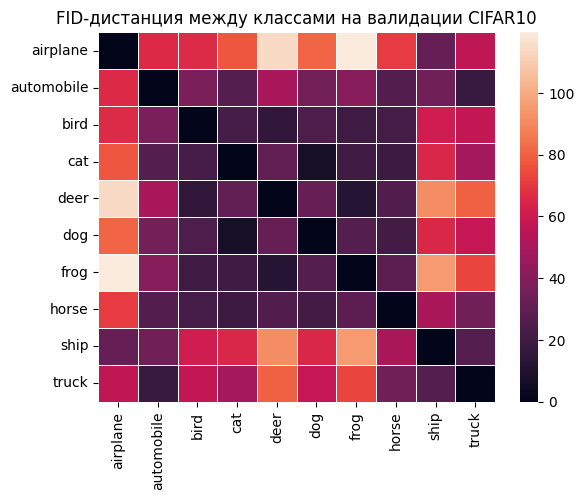

In [64]:
sns.heatmap(
    heatmap, 
    linewidth=0.5, 
    xticklabels=text_labels, 
    yticklabels=text_labels
)
plt.title('FID-дистанция между классами на валидации CIFAR10')
plt.show()

## Задание 3 (3 балла)

Возьмите **любой** датасет из интернета, в котором есть **два разных класса** (например, «кошки и собаки», или какие-то другие). Посчитайте между ними FID, используя **тот же энкодер** (обученный на CIFAR10).

In [22]:
import os
import torch
import kagglehub
import torchvision.transforms as transforms
from torchvision.io import read_image
from torchvision.transforms.functional import to_pil_image
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

In [ ]:
dataset_path = os.path.join(kagglehub.dataset_download("jehanbhathena/weather-dataset"), "dataset")
rain_path = os.path.join(dataset_path, "rain")
rainbow_path = os.path.join(dataset_path, "rainbow")

class_map = {"rain": 0, "rainbow": 1}
data, labels = [], []

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

def load_images_from_folder(folder, label):
    for img_name in tqdm(os.listdir(folder), desc=f"Обработка {folder}"):
        img_path = os.path.join(folder, img_name)

        if os.path.isfile(img_path):
            image = read_image(img_path).float() / 255.0
            image = to_pil_image(image) 
            image = image.convert("RGB")
            image = transform(image)
            data.append(image)
            labels.append(label)

load_images_from_folder(rain_path, class_map["rain"])
load_images_from_folder(rainbow_path, class_map["rainbow"])

data = torch.stack(data)  # (N, C, H, W)
labels = torch.tensor(labels)

torch.save((data, labels), "weather_dataset.pt")
print("Датасет сохранен как weather_dataset.pt")

Обработка /home/avomilas/.cache/kagglehub/datasets/jehanbhathena/weather-dataset/versions/3/dataset/rain: 100%|██████████| 526/526 [00:05<00:00, 90.23it/s] 
Обработка /home/avomilas/.cache/kagglehub/datasets/jehanbhathena/weather-dataset/versions/3/dataset/rainbow:  24%|██▍       | 56/232 [00:00<00:01, 110.70it/s]libpng warning: iCCP: known incorrect sRGB profile
Обработка /home/avomilas/.cache/kagglehub/datasets/jehanbhathena/weather-dataset/versions/3/dataset/rainbow: 100%|██████████| 232/232 [00:02<00:00, 85.89it/s] 


Датасет сохранен как weather_dataset.pt


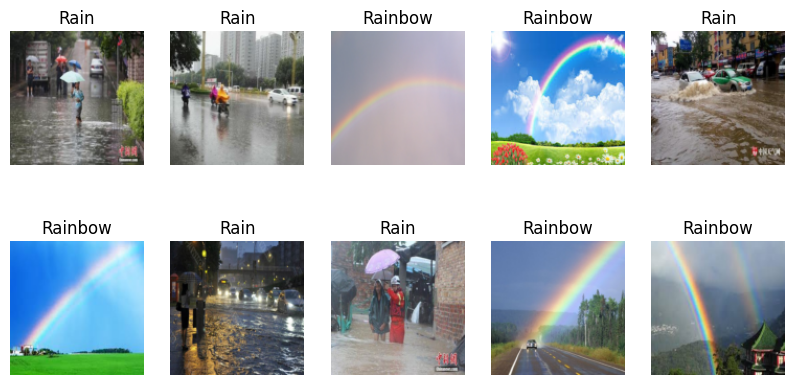

In [31]:
data, labels = torch.load("weather_dataset.pt", weights_only=False)

dataset = TensorDataset(data, labels)
dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

class_names = {0: "Rain", 1: "Rainbow"}
text_labels = ['Rain', 'Rainbow']

def show_images(images, labels):
    plt.figure(figsize=(10, 5))
    for i in range(len(images)):
        plt.subplot(2, 5, i + 1)  # Сетка 2x5
        img = images[i].permute(1, 2, 0).numpy()  # (C, H, W) -> (H, W, C)
        plt.imshow(img)
        plt.title(class_names[labels[i].item()])
        plt.axis("off")
    plt.show()

images, labels = next(iter(dataloader))
show_images(images, labels)

In [28]:
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)
representations = get_representations(dataloader, encoder, device)

In [29]:
heatmap = np.zeros((2, 2))
for label_from in trange(2):
    for label_to in range(2):
        fid = calculate_fid(
            torch.stack(representations[label_from], dim=0).detach().cpu().numpy(),
            torch.stack(representations[label_to], dim=0).detach().cpu().numpy()
        )
        heatmap[label_from, label_to] = fid

  0%|          | 0/2 [00:00<?, ?it/s]

/tmp/ipykernel_2066/1207358572.py:8: ComplexWarning: Casting complex values to real discards the imaginary part
  heatmap[label_from, label_to] = fid
100%|██████████| 2/2 [00:52<00:00, 26.49s/it]


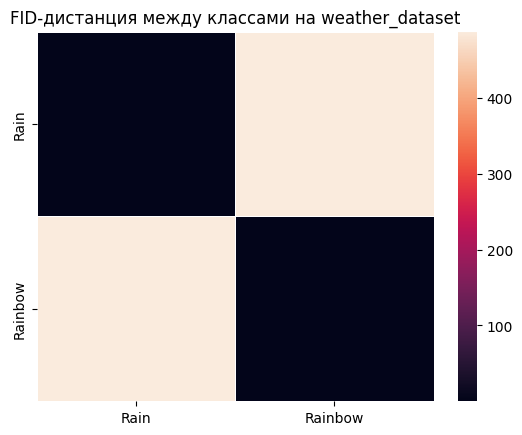

In [ ]:
sns.heatmap(
    heatmap, 
    linewidth=0.5, 
    xticklabels=text_labels, 

    yticklabels=text_labels
)
plt.title('FID-дистанция между классами на weather_dataset')
plt.show()

## Задание 4 (1 балл)

Поздравляем, вы проделали большую работу! В этом разделе:
1. Опишите идеи, которые вы хотели бы попробовать, если бы у вас было больше времени или статьи, в которых решают подобные задачи.  
2. Приложите какой-нибудь свежий (последних пары лет) мем про генеративные модели. Если мем будет не смешным, увы, придётся снять баллы.

Я бы хотела поработать с составными автоэнкодерами, например, с несколькими латентными состояниями - чтобы отдельно улавливались общие характеристики и детали. Или же, например, стилистические автоэнкодеры, где отдельно кодируется структура и отдельно стиль, благодаря чему можно создавать разные комбинации стиля и содержательного контента


<img src="https://i.ibb.co/RT7WX24R/photo-2025-02-02-19-46-36.jpg" alt="Описание изображения" width="500">
<img src="https://i.ibb.co/WNKMvVMs/photo-2025-02-03-01-27-22.jpg" alt="Описание изображения" width=500">


<img src="https://i.ibb.co/F4rhT5LJ/photo-2025-02-04-22-32-55.jpg" alt="Описание изображения" width="400">
<img src="https://i.ibb.co/b50MRvQW/photo-2025-02-03-01-32-59.jpg" alt="Описание изображения" width="400">
<img src="https://i.ibb.co/8L015JJv/photo-2025-02-03-01-28-49.jpg" alt="Описание изображения" width="330">
